In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def f(x):
    return np.exp(-50*(x-1/2)**2)

/var/folders/4g/2pt8l_5d2293mfwd1zz3bzlr0000gr/T/ipykernel_77450/1079699459.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  Fx_k[k]=sum
/var/folders/4g/2pt8l_5d2293mfwd1zz3bzlr0000gr/T/ipykernel_77450/1079699459.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  Fx_k_an[k] = np.exp(-1j * k / 2) * np.exp(-k**2 / 200) * np.sqrt(np.pi / 50)
/var/folders/4g/2pt8l_5d2293mfwd1zz3bzlr0000gr/T/ipykernel_77450/1079699459.py:39: ComplexWarning: Casting complex values to real discards the imaginary part
  inv_func[n] = 1/N * inv_sum


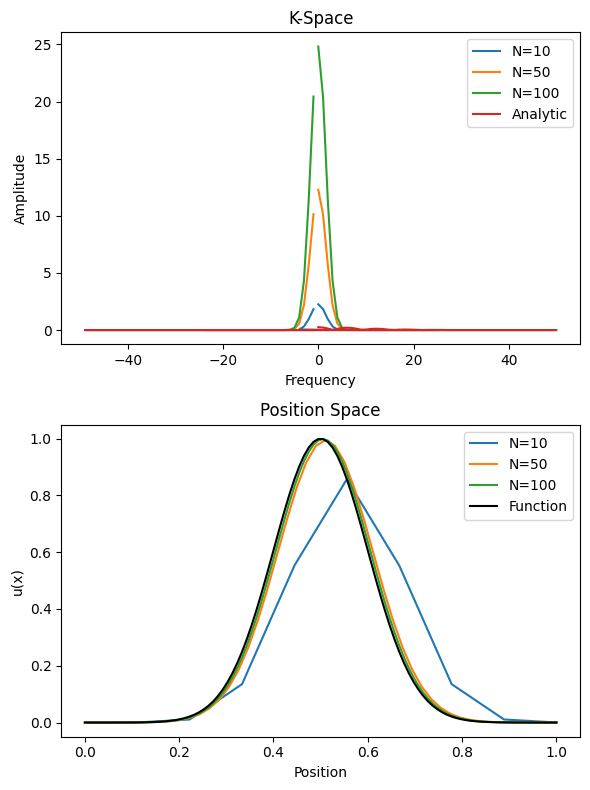

In [336]:
N_arr = [10,50,100]
fig, ax = plt.subplots(2, 1, figsize=(6, 8))

for N in N_arr:

    #create physical interpretation of frequencies
    k_phys = np.zeros(N)
    for k in range(N):
        if k <= N//2:
            k_phys[k] = k
        else:
            k_phys[k] = k - N

    #create an evenly spaced sample of the domain
    sample = np.linspace(0, 1, N)
    fx_n = f(sample)

    #discrete summation for each index in k-space
    Fx_k = np.zeros(N)
    Fx_k_an = np.zeros(N)
    for k in range(N):
        sum = 0
        for n in range(N):
            sum += fx_n[n] * np.exp(-1j * 2*np.pi * k/N * n)
        Fx_k[k]=sum

        #compute transform values for analytic result
        Fx_k_an[k] = np.exp(-1j * k / 2) * np.exp(-k**2 / 200) * np.sqrt(np.pi / 50)

    #plot transformed results
    ax[0].plot(k_phys, np.abs(Fx_k), label=f'N={N}')

    #invert back to position space
    inv_func = np.zeros(N)
    for n in range(N):
        inv_sum=0
        for k in range(N):
            inv_sum += Fx_k[k] * np.exp(1j * 2*np.pi * k/N * n) 
        inv_func[n] = 1/N * inv_sum

    #plot inverse results
    ax[1].plot(sample, inv_func, label=f'N={N}')

ax[0].set_title("K-Space")
ax[1].set_title("Position Space")

ax[0].set_xlabel('Frequency')
ax[0].set_ylabel('Amplitude')
ax[1].set_xlabel('Position')
ax[1].set_ylabel('u(x)')

ax[0].plot(k_phys, np.abs(Fx_k_an), label='Analytic')
ax[1].plot(sample, f(sample), label='Function', color='black')

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
import time

#repeat last part but wrap in a function to time it
def DFT(min, max, N, func):

    sample = np.linspace(min, max, N)
    fx_n = func(sample)
    Fx_k = np.zeros(N)

    start = time.time()

    for k in range(N):
        sum = 0
        for n in range(N):
            sum += fx_n[n] * np.exp(-1j * 2*np.pi * k/N * n)
        Fx_k[k]=sum

    end = time.time()

    return(Fx_k, end-start)

In [ ]:
from scipy.fft import fft

#wrap package in function to time
def FFT(min, max, N, func):

    sample = np.linspace(min, max, N)
    fx_n = func(sample)

    start = time.time()

    Fx_k = fft(fx_n)

    end = time.time()

    return(Fx_k, end-start)

/var/folders/4g/2pt8l_5d2293mfwd1zz3bzlr0000gr/T/ipykernel_77450/643419568.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  Fx_k[k]=sum


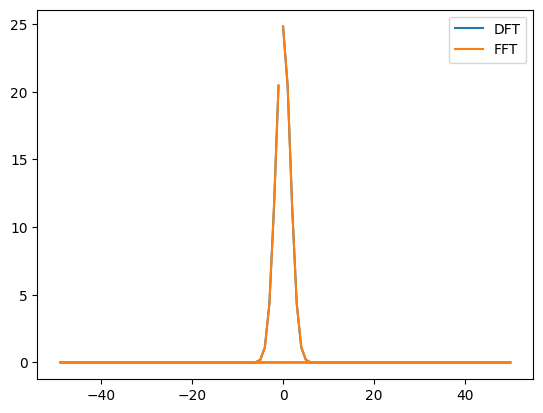

In [339]:
Y_DFT = DFT(0,1,100,f)[0]
Y_FFT = FFT(0,1,100,f)[0]

plt.plot(k_phys,np.abs(Y_DFT), label='DFT')
plt.plot(k_phys,np.abs(Y_FFT), label='FFT')
plt.legend()

In [ ]:
N_DFT = 2 ** (np.arange(3,12))
N_FFT = 2 ** (np.arange(3,21))

nruns = 100
time_DFT = np.zeros(len(N_DFT))
time_FFT = np.zeros(len(N_FFT))

#run all N values for DFT, nruns times, and store time averages
for n in range(len(N_DFT)):
    N = N_DFT[n]

    for r in range(nruns):
        t_r = DFT(0,1,N,f)[1]
        time_DFT[n] += t_r

    time_DFT[n] = time_DFT[n] / nruns

/var/folders/4g/2pt8l_5d2293mfwd1zz3bzlr0000gr/T/ipykernel_77450/1767007285.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  Fx_k[k]=sum


In [ ]:
#run all N values for FFT, nruns times, and store time averages
for n in range(len(N_FFT)):
    N = N_FFT[n]

    for r in range(nruns):
        t_r = FFT(0,1,N,f)[1]
        time_FFT[n] += t_r

    time_FFT[n] = time_FFT[n] / nruns

Text(0.5, 1.0, 'DFT Runs')

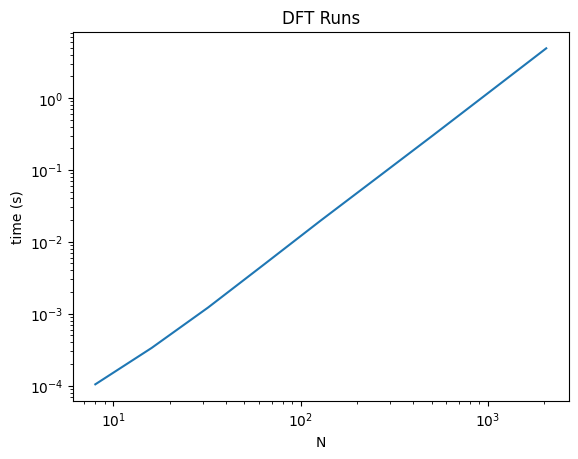

In [341]:
plt.plot(N_DFT, time_DFT)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('time (s)')
plt.title('DFT Runs')

Text(0.5, 1.0, 'FFT Runs')

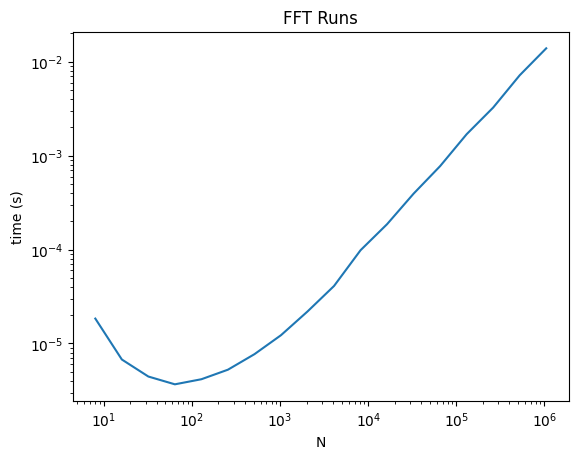

In [342]:
plt.plot(N_FFT, time_FFT)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('time (s)')
plt.title('FFT Runs')

In [ ]:
#copied old runge_kutta function
def runge_kutta(num_steps, h, x0, y0, f_xy):
    x = np.array([x0])
    y = np.array([y0])

    k1 = np.array([f_xy(x0,y0)])
    k2 = np.array([f_xy(x0+h/2, y0 + k1[0] * h/2)])
    k3 = np.array([f_xy(x0+h/2, y0 + k2[0] * h/2)])
    k4 = np.array([f_xy(x0+h, y0 + k3[0] * h)])
    
    for i in range(num_steps):
        x = np.append(x, x[-1]+h)
        y = np.append(y, y[-1] + h/6 * (k1[-1] + 2*k2[-1] + 2*k3[-1] + k4[-1]))

        k1 = np.append(k1, f_xy(x[-1],y[-1]))
        k2 = np.append(k2, f_xy(x[-1]+h/2, y[-1] + k1[-1] * h/2))
        k3 = np.append(k3, f_xy(x[-1]+h/2, y[-1] + k2[-1] * h/2))
        k4 = np.append(k4, f_xy(x[-1]+h, y[-1] + k3[-1] * h))

    return x, y, k1, k2, k3, k4

In [ ]:
from scipy.fft import ifft

alpha = 0.005
dt = 0.001
Nk = 100

def heat_plot(alpha, dt, T, Nk):

    #store array of initial distribution in k-space
    u_k0 = DFT(0, 1, N, f)[0]
    u_k = []

    #loop over k values, finding the time evolution for each k
    for k in range(Nk):

        def heat_eq(t,u):
            return -alpha * (2*np.pi*k)**2 * u
        
        t,u,_,_,_,_ = runge_kutta(int(T/dt-1), dt, 0, u_k0[k], heat_eq)
        u_k.append(u)

    u_k = np.array(u_k)

    # since each row is time evolution of one k, we need to transpose matrix 
    # to get all k at one time
    u_xt = np.real(ifft(u_k.T))
    plt.imshow(u_xt, aspect='auto', extent=[0,1,0,5], origin='lower')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.colorbar(label='u(x,t)')
    plt.title('Heat Equation Evolution')
    plt.show()

/var/folders/4g/2pt8l_5d2293mfwd1zz3bzlr0000gr/T/ipykernel_77450/643419568.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  Fx_k[k]=sum


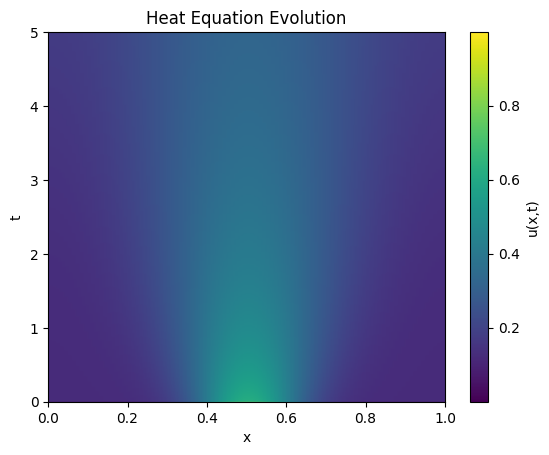

In [301]:
heat_plot(alpha, dt, 5, Nk)

Text(0.5, 1.0, 'Total Heat')

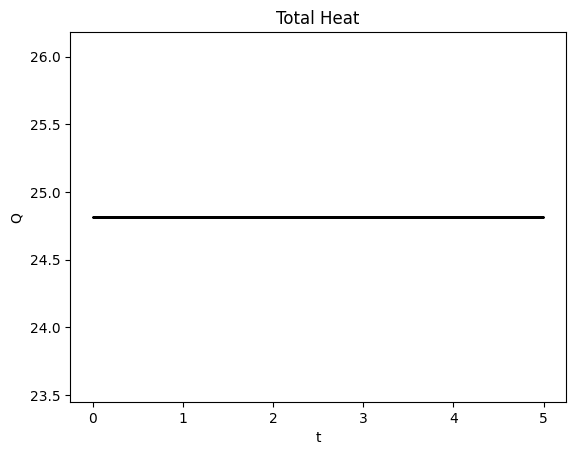

In [343]:
#find total heat
Q = np.sum(u_xt, axis=1)
plt.xlabel('t')
plt.ylabel('Q')
plt.scatter(np.arange(0,5,h), Q, s=0.1, color='black')
plt.title('Total Heat')

/var/folders/4g/2pt8l_5d2293mfwd1zz3bzlr0000gr/T/ipykernel_77450/643419568.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  Fx_k[k]=sum


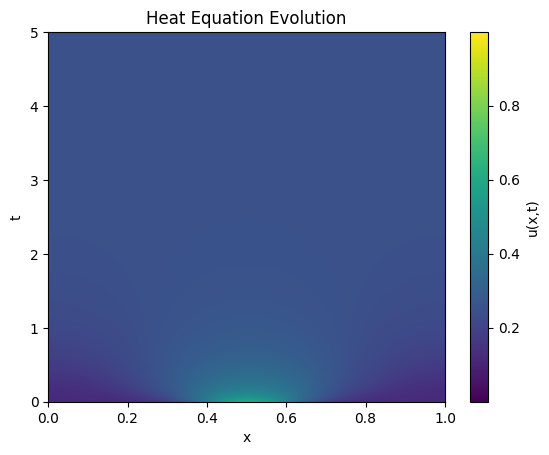

In [315]:
heat_plot(alpha=0.05, dt=0.0001, T=5, Nk=100)